# Testing Exported Models from Teachable Machine.
This notebook contains example code to use machine learning models exported from Teachable Machine and test them with images of out choice. Please follow the instructions below.
1. Export and Download your model from the Teachable Machine Website. It should give you a zip file.
2. Upload the zip file to google colab.
3. Upload your test dataset as a zip file.
4. Run the cells below to extract the zip files.

In [ ]:
# Extract the model and the class labels
!unzip /content/converted_keras.zip

Archive:  /content/converted_keras.zip
 extracting: keras_model.h5          
 extracting: labels.txt              


In [ ]:
# Extract the dataset
!unzip /content/Animal_Dataset-20230905T200929Z-001.zip

In [ ]:
# Importing necessary libraries

from keras.models import load_model  # TensorFlow is required for Keras to work
from PIL import Image, ImageOps  # Install pillow instead of PIL
import numpy as np
from google.colab import files
from io import BytesIO
import matplotlib.pyplot as plt

### Making Predictions on one image at a time.

Please upload an image you want to make a prediction on.
ONLY ONE IMAGE AT A TIME


Saving cat-t3.png to cat-t3.png


1/1 [==============================] - 1s 660ms/step


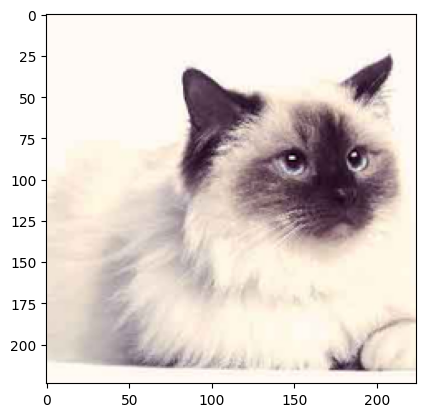

Class: Cat
Confidence Score: 0.99998355


In [ ]:
# This code is provided by the Teachable Machine website.
# It shows how to load the trained model and perform prediction on 1 image at a time.



# Disable scientific notation for clarity
np.set_printoptions(suppress=True)

# Load the model
model = load_model("/content/keras_model.h5", compile=False)

# Load the labels
class_names = open("/content/labels.txt", "r").readlines()

# Create the array of the right shape to feed into the keras model
# The 'length' or number of images you can put into the array is
# determined by the first position in the shape tuple, in this case 1
data = np.ndarray(shape=(1, 224, 224, 3), dtype=np.float32)

print(f"Please upload an image you want to make a prediction on.")
print(f"ONLY ONE IMAGE AT A TIME")
my_file = files.upload()

if len(my_file) > 1:
  raise Exception(f"You have tried uploading more than one images!")


# Assuming you've uploaded only one image; otherwise, you'll need to specify the filename
filename = list(my_file.keys())[0]
image = Image.open(BytesIO(my_file[filename])).convert('RGB')


# resizing the image to be at least 224x224 and then cropping from the center
size = (224, 224)
image = ImageOps.fit(image, size, Image.Resampling.LANCZOS)

# turn the image into a numpy array
image_array = np.asarray(image)

# Normalize the image
normalized_image_array = (image_array.astype(np.float32) / 127.5) - 1

# Load the image into the array
data[0] = normalized_image_array

# Predicts the model
prediction = model.predict(data)
index = np.argmax(prediction)
class_name = class_names[index]
confidence_score = prediction[0][index]

plt.imshow(image)
plt.show()

# Print prediction and confidence score
print("Class:", class_name[2:], end="")
print("Confidence Score:", confidence_score)


### Generating Classification report for the model

In [ ]:
# Load the required packages
from keras.models import load_model
from keras.preprocessing.image  import ImageDataGenerator
from PIL import Image, ImageOps
from sklearn import metrics
import numpy as np

# Load the data
data_path = '/content/Animal_Dataset/Testing'
test_generator = ImageDataGenerator(rescale=1./255)
test_generator = test_generator.flow_from_directory(directory=data_path,
                                                    target_size=(224, 224),
                                                    batch_size=16,
                                                    shuffle=False)

Found 200 images belonging to 4 classes.


In [ ]:
# Make predictions on all images in the test set
predictions = model.predict(test_generator)

# Get the predicted class
predictions = np.argmax(predictions,axis = -1)

# Print the predictions and the ground truth labels
print(f"Predictions: {predictions}")
print(f"Labels: {test_generator.labels}")

13/13 [==============================] - 3s 160ms/step
Predictions: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 3 1 1 1 1 1 1 3 1 1 3 1
 1 1 3 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 1 3 3 3 3 3]
Labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]


In [ ]:
print(metrics.classification_report(test_generator.labels,predictions))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        50
           1       0.98      0.88      0.93        50
           2       1.00      0.96      0.98        50
           3       0.91      0.98      0.94        50

    accuracy                           0.95       200
   macro avg       0.96      0.95      0.95       200
weighted avg       0.96      0.95      0.95       200

